In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Matplotlib is building the font cache; this may take a moment.


In [2]:
real_path = "dataset/real"
fake_path = "dataset/fake"

print("Real Images:", len(os.listdir(real_path)))
print("Fake Images:", len(os.listdir(fake_path)))

Real Images: 589
Fake Images: 700


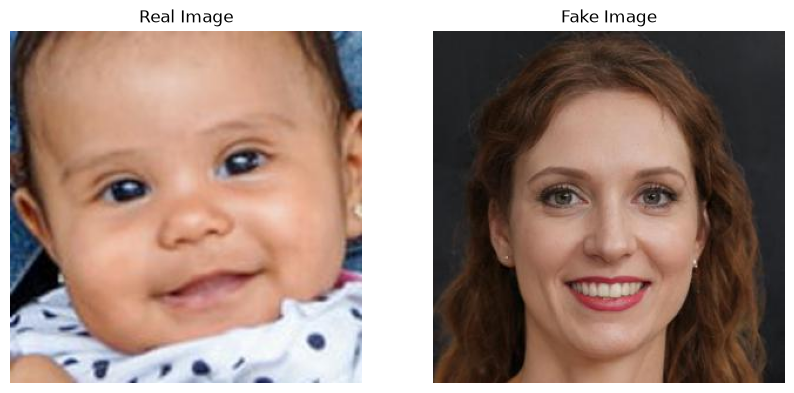

In [3]:
import random

plt.figure(figsize=(10,5))

# Display a Real Image
real_image = random.choice(os.listdir(real_path))
real_img = cv2.imread(os.path.join(real_path, real_image))
real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(real_img)
plt.title("Real Image")
plt.axis("off")

# Display a Fake Image
fake_image = random.choice(os.listdir(fake_path))
fake_img = cv2.imread(os.path.join(fake_path, fake_image))
fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,2)
plt.imshow(fake_img)
plt.title("Fake Image")
plt.axis("off")

plt.show()

In [4]:
IMG_SIZE = 128

images = []
labels = []

# Load Real Images
for img_name in os.listdir(real_path):
    img_path = os.path.join(real_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        images.append(img)
        labels.append(0)

# Load Fake Images
for img_name in os.listdir(fake_path):
    img_path = os.path.join(fake_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        images.append(img)
        labels.append(1)

images = np.array(images)
labels = np.array(labels)

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Images Shape: (1289, 128, 128, 3)
Labels Shape: (1289,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (1031, 128, 128, 3)
Testing Images: (258, 128, 128, 3)


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\suman\Deepfake-Detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.8603 - loss: 0.3242 - val_accuracy: 0.9922 - val_loss: 0.0490
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.9932 - loss: 0.0278 - val_accuracy: 0.9961 - val_loss: 0.0472
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.9971 - loss: 0.0108 - val_accuracy: 0.9961 - val_loss: 0.0321
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.9990 - loss: 0.0065 - val_accuracy: 0.9961 - val_loss: 0.0349
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 1.0000 - loss: 4.8039e-04 - val_accuracy: 0.9961 - val_loss: 0.0450
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9961 - loss: 0.0102 - val_accuracy: 0.9961 - val_loss: 0.0521
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step - accuracy: 0.9971 - loss: 0.0125 - val_accuracy: 0.9961 - val_loss: 0.0513
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.9981 - loss: 0.0069 - val_accuracy

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9961 - loss: 0.0422
Test Accuracy: 0.9961240291595459
Test Loss: 0.04223211482167244


In [9]:
model.save("deepfake_model.keras")
print("Model saved successfully!")

Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


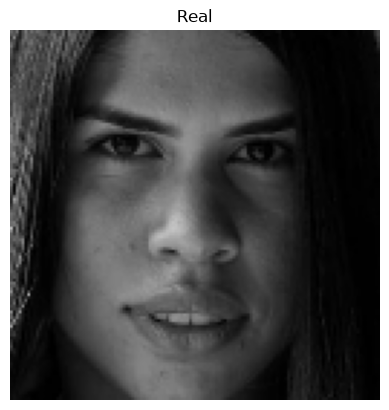

Prediction: Real
Confidence: 5.594628e-09


In [10]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = load_model("deepfake_model.keras")

# Image path
img_path = "dataset/real/real_1.jpg"

# Read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (128, 128))

# Prepare image
input_img = img / 255.0
input_img = np.expand_dims(input_img, axis=0)

# Predict
prediction = model.predict(input_img)

if prediction[0][0] > 0.5:
    result = "Fake"
else:
    result = "Real"

plt.imshow(img)
plt.title(result)
plt.axis("off")
plt.show()

print("Prediction:", result)
print("Confidence:", prediction[0][0])